# Preliminaries



## imports

In [ ]:
import warnings
import pandas as pd
import re
import random as rnd
import csv
from pandas.errors import SettingWithCopyWarning
import matplotlib.pyplot as plt
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)
import csv
csv.field_size_limit(10**7)

#display rendering, check this, CHECK LAMBDA
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 100)

## file loading

In [ ]:
# Brands
url = "https://drive.google.com/file/d/1XWetCoHpTAzXhBQCtYtGjI_kFV2XbmB4/view?usp=sharing" # brands.csv
brands = pd.read_csv("https://drive.google.com/uc?export=download&id="+url.split("/")[-2])

# Orderlines

url = "https://drive.google.com/file/d/1aF216UIcxk0PEpdMU-GjfXIx3ren9a-u/view?usp=sharing" # orderlines.csv
orderlines = pd.read_csv("https://drive.google.com/uc?export=download&id="+url.split("/")[-2])

# Orders
url = "https://drive.google.com/file/d/1oxsH8mClTJ07EWjgd83J8MEio05L_6A0/view?usp=sharing" # orders.csv
orders = pd.read_csv("https://drive.google.com/uc?export=download&id="+url.split("/")[-2])

# Products
url = "https://drive.google.com/file/d/11WfFj0_24afGj-1nDWyPJemRBwlc3PVt/view?usp=sharing" # products.csv
products = pd.read_csv("https://drive.google.com/uc?export=download&id="+url.split("/")[-2])
bd   = brands
od   = orders
ol   = orderlines
prod = products

## category and string cleaning

In [ ]:
#initial data cleaning
#drop all duplicates; there are 8750 duplicates in prod
prod = prod.drop_duplicates()

#delete rows bc its so few; 5 inimp od, <104 in prod; there are no other duplicates
od.dropna(axis=0)
prod.dropna(axis=0) #check how that affects price

#fixing the second "." in unitprice, promo price
ol['unit_price'] = ol['unit_price'].astype(str)
ol["unit_price"] = ol["unit_price"].str.replace(r'\.(?=.*\.)', '', regex=True)
prod["price"] = prod["price"].str.replace(r'^[^.]*$',r'\g<0>.00', regex=True) # this adds ".00" to prices that have no dot
#drop all non standard formatted entries for prod/pricing
bad_price = (
    prod['price'].str.contains(r"\d+\.\d+\.\d+", na=False) |
    prod['price'].str.contains(r"\d+\.\d{3,}", na=False)
)
prod = prod.loc[~bad_price].copy() #its like 10k lines

#change unittypes
ol["unit_price"] = ol["unit_price"].astype(float)
prod["price"] = prod["price"].astype(float)
od["created_date"] = pd.to_datetime(od["created_date"])
ol["date"] = pd.to_datetime(ol["date"])
#prod['price'] = pd.to_numeric(prod['price'], errors='coerce')
# fix type column
prod["type"] = (
    prod["type"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)
prod["type"] = pd.to_numeric(prod["type"], errors="coerce")

## Database filtering and merging

In [ ]:
#filter orders by completed, pending, order_place
od = od.loc[od["state"].isin(["Completed", "Pending", "Place Order"])]
#merge orders and orderlines on order_id; merge products
mydata = pd.merge(od, ol, how="left", left_on="order_id", right_on="id_order")
mydata = pd.merge(mydata, prod, how="left", left_on="sku", right_on="sku")
mydata = mydata[(mydata["total_paid"] > mydata["unit_price"]) | (mydata["state"] != "completed")] #filter all prices wehre total price is smaller than the unit price, unless its not completed yet

#remove prices <=0
mydata = mydata.loc[(mydata["unit_price"] > 0),:]
mydata = mydata.loc[(mydata['price'] > 0), :]
mydata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111906 entries, 0 to 127659
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   order_id          111906 non-null  int64         
 1   created_date      111906 non-null  datetime64[ns]
 2   total_paid        111900 non-null  float64       
 3   state             111906 non-null  object        
 4   id                111906 non-null  float64       
 5   id_order          111906 non-null  float64       
 6   product_id        111906 non-null  float64       
 7   product_quantity  111906 non-null  float64       
 8   sku               111906 non-null  object        
 9   unit_price        111906 non-null  float64       
 10  date              111906 non-null  datetime64[ns]
 11  name              111906 non-null  object        
 12  desc              111902 non-null  object        
 13  price             111906 non-null  float64       
 14  promo_pri

In [ ]:
#fix outeliers in unit_price, price
Q1 = mydata["unit_price"].quantile(0.25)
Q3 = mydata["unit_price"].quantile(0.75)
IQR = Q3-Q1
mydata = mydata.loc[ (mydata["unit_price"] >= (Q1 - 4.1*IQR)) & (mydata["unit_price"] <= (Q3 + 4.1*IQR)),:]
mydata = mydata.loc[ (mydata["price"] >= (Q1 - 4.1*IQR)) & (mydata["price"] <= (Q3 + 4.1*IQR)),:]

#mydata.boxplot(column="unit_price")
#mydata.boxplot(column="price")
#plt.show()


# First Analysis (Discount, Buckets, Discount Plotting)

## descriptives

In [ ]:
print('✅ brands    :', brands.shape)
print('✅ orderlines:', orderlines.shape)
print('✅ orders    :', orders.shape)
print('✅ products  :', products.shape)

✅ brands    : (187, 2)
✅ orderlines: (293983, 7)
✅ orders    : (226909, 4)
✅ products  : (19326, 7)


In [ ]:
mydata.info()
print(mydata["sku"].nunique())
print((mydata["price"] == 0).sum())

<class 'pandas.core.frame.DataFrame'>
Index: 104014 entries, 0 to 127659
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   order_id          104014 non-null  int64         
 1   created_date      104014 non-null  datetime64[ns]
 2   total_paid        104009 non-null  float64       
 3   state             104014 non-null  object        
 4   id                104014 non-null  float64       
 5   id_order          104014 non-null  float64       
 6   product_id        104014 non-null  float64       
 7   product_quantity  104014 non-null  float64       
 8   sku               104014 non-null  object        
 9   unit_price        104014 non-null  float64       
 10  date              104014 non-null  datetime64[ns]
 11  name              104014 non-null  object        
 12  desc              104010 non-null  object        
 13  price             104014 non-null  float64       
 14  promo_pri

In [ ]:
types = mydata["type"].value_counts().head(50)
print(types)

type
11865403.00     8312
11935397.00     7329
11905404.00     5628
1364.00         5562
5384.00         4068
12215397.00     3841
12655397.00     3546
12585395.00     3359
1231.00         2998
1296.00         2860
1230.00         2780
1405.00         2413
1325.00         2178
12175397.00     2137
13835403.00     1932
51601716.00     1600
13855401.00     1559
12755395.00     1551
42945397.00     1522
13555403.00     1498
1229.00         1496
12635403.00     1425
13615399.00     1407
1433.00         1305
113281716.00    1296
10142.00        1285
5398.00         1276
13005399.00     1247
12995397.00     1216
1387.00         1181
57445397.00     1164
14305406.00     1163
24895185.00     1033
5395.00          980
85651716.00      942
1515.00          932
1334.00          883
1298.00          881
85641716.00      876
12645406.00      854
113291716.00     837
8696.00          708
12575403.00      707
1392.00          655
1714.00          632
106431714.00     624
2449.00          504
21485407

## Discount Calculation

### Generating Discount (inkl. Buckets)

#### Discount Calc

In [ ]:
#calculate discounts based on the highest price in "unit_price"
mydata["delta"] = mydata["price"] - mydata["unit_price"]
mydata = mydata.loc[(mydata["delta"] >= 0),:] # this removes any cases where unit_price could be higher than price to fix "unit price"

#calculate the discount as the percentage of unit_price from price
mydata["discount"] = 100 - (mydata["unit_price"] / (mydata["price"]/100))

#calculate total price per product ordered
mydata["t_price"] = mydata["price"] * mydata["product_quantity"]


#### Discount Bucket

In [ ]:
def bucketfilter(row):
    if row == 0: return 0
    if row < 11: return 1
    if row < 34: return 2
    if row < 51: return 3
    else: return 4

mydata["d_buckets"] = mydata["discount"].apply(bucketfilter)

#### Monthwise buckets

In [ ]:
# ── MONTH-WISE DISCOUNT BUCKETS ──────────────────────────────────────────

import matplotlib.ticker as mticker

# Extract month
mydata['month'] = mydata['date'].dt.to_period('M')

# Count orders + revenue per bucket per month
monthly_buckets = (
    mydata
    .groupby(['month', 'd_buckets'])
    .agg(orders=('order_id', 'nunique'), revenue=('t_price', 'sum'))
    .reset_index()
)

bucket_labels = {0: 'No Discount', 1: '1-10%', 2: '11-33%', 3: '34-50%', 4: '51%+'}
monthly_buckets['bucket_label'] = monthly_buckets['d_buckets'].map(bucket_labels)

print('Monthly discount bucket breakdown:')
print(monthly_buckets.to_string(index=False))

Monthly discount bucket breakdown:
  month  d_buckets  orders    revenue bucket_label
2017-01          0     422   45434.47  No Discount
2017-01          1    1749  424894.99        1-10%
2017-01          2    3743  532435.05       11-33%
2017-01          3    1038   87797.24       34-50%
2017-01          4    1169   86383.96         51%+
2017-02          0     233   29987.63  No Discount
2017-02          1    1366  378482.42        1-10%
2017-02          2    2558  415377.36       11-33%
2017-02          3     549   44828.93       34-50%
2017-02          4     411   42035.23         51%+
2017-03          0     393   46805.72  No Discount
2017-03          1    1191  326890.06        1-10%
2017-03          2    2055  356688.35       11-33%
2017-03          3     525   33216.34       34-50%
2017-03          4     178   14956.45         51%+
2017-04          0     267   28121.31  No Discount
2017-04          1    1256  301436.61        1-10%
2017-04          2    1929  386106.51       11-

### Discount vs no Discount

In [ ]:
# Discounted vs No Discount per month
mydata['is_discounted'] = mydata['d_buckets'] > 0

monthly_summary = (
    mydata
    .groupby(['month', 'is_discounted'])
    .agg(orders=('order_id', 'nunique'), revenue=('t_price', 'sum'))
    .reset_index()
)
monthly_summary['is_discounted'] = monthly_summary['is_discounted'].map(
    {True: 'Discounted', False: 'No Discount'}
)
print('Monthly revenue: Discounted vs No Discount')
print(monthly_summary.to_string(index=False))

Monthly revenue: Discounted vs No Discount
  month is_discounted  orders    revenue
2017-01   No Discount     422   45434.47
2017-01    Discounted    6847 1131511.24
2017-02   No Discount     233   29987.63
2017-02    Discounted    4394  880723.94
2017-03   No Discount     393   46805.72
2017-03    Discounted    3555  731751.20
2017-04   No Discount     267   28121.31
2017-04    Discounted    3452  735800.52
2017-05   No Discount     317   31459.05
2017-05    Discounted    3370  767267.13
2017-06   No Discount     278   50297.47
2017-06    Discounted    3208  816795.02
2017-07   No Discount     240   35390.51
2017-07    Discounted    4897 1181225.93
2017-08   No Discount     186   23333.91
2017-08    Discounted    3361  793226.90
2017-09   No Discount     232   38426.56
2017-09    Discounted    3661 1009086.15
2017-10   No Discount     255   49098.07
2017-10    Discounted    4700 1304176.77
2017-11   No Discount     262   51010.05
2017-11    Discounted   11269 3467752.56
2017-12   No D

In [ ]:
# Share of discounted orderlines
# 1. Ensure you only count items that had a discount applied
discounted_only = mydata[mydata['d_buckets'] > 0].copy()

# 2. Get the count of every bucket
# Use 'size()' to count the number of orderlines
bucket_counts = discounted_only.groupby('d_buckets').size()

# 3. Calculate the percentage of total discounted orderlines
# This is the 'share' you were asking for
bucket_shares = (bucket_counts / len(discounted_only)) * 100

# 4. Map the labels for readability
bucket_labels = {1: '1-10%', 2: '11-33%', 3: '34-50%', 4: '51%+'}
results = pd.DataFrame({
    'Bucket': [bucket_labels[b] for b in bucket_counts.index],
    'Percentage': bucket_shares.values
})

print("Share of each bucket out of total discounted orderlines:")
print(results.to_string(index=False))

Share of each bucket out of total discounted orderlines:
Bucket  Percentage
 1-10%       28.80
11-33%       53.89
34-50%        9.73
  51%+        7.58


is_discounted     revenue  orders  units_sold
  No Discount   678693.16    4300     5034.00
   Discounted 19516583.14   75863   107513.00


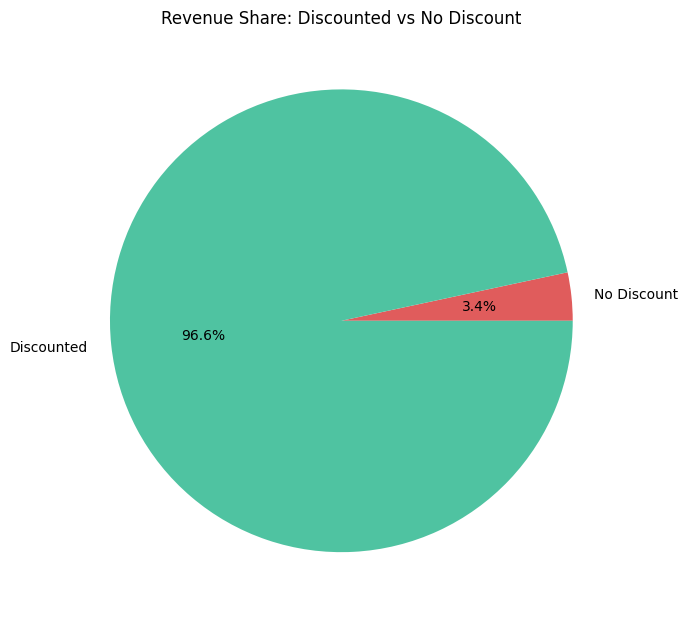

In [ ]:
# Revenue split: Discounted vs No Discount
rev_split = (
    mydata
    .groupby('is_discounted')
    .agg(
        revenue   = ('t_price', 'sum'),
        orders    = ('order_id', 'nunique'),
        units_sold= ('product_quantity', 'sum')
    )
    .reset_index()
)
rev_split['is_discounted'] = rev_split['is_discounted'].map(
    {True: 'Discounted', False: 'No Discount'}
)
print(rev_split.to_string(index=False))

# Pie chart
rev_split.set_index('is_discounted')['revenue'].plot(
    kind='pie', autopct='%1.1f%%', figsize=(7, 7),
    title='Revenue Share: Discounted vs No Discount',
    colors=['#e05c5c', '#4fc3a1']
)
plt.ylabel('')
plt.tight_layout()
plt.show()

### Orders x Bucket x Month

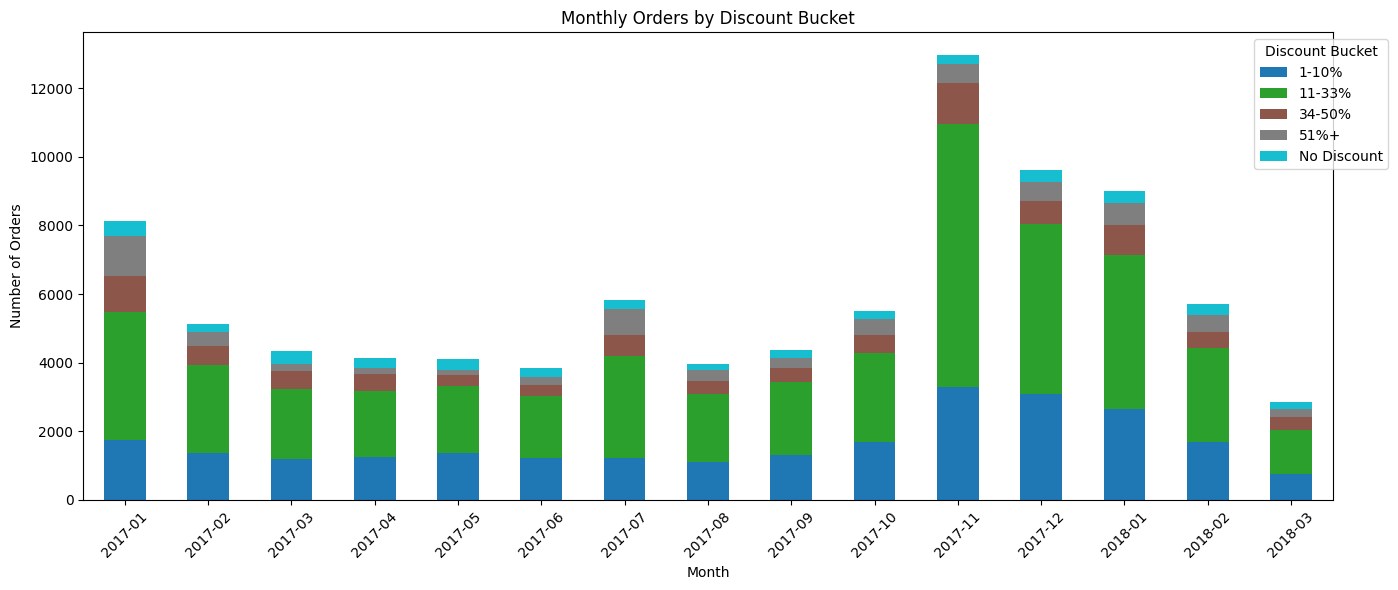

In [ ]:
# Pivot + plot orders by bucket per month
pivot_orders = monthly_buckets.pivot_table(
    index='month', columns='bucket_label', values='orders', aggfunc='sum'
).fillna(0)

ax = pivot_orders.plot(
    kind='bar', stacked=True, figsize=(14, 6),
    colormap='tab10', title='Monthly Orders by Discount Bucket'
)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.legend(title='Discount Bucket', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Revenue x Bucket x Month

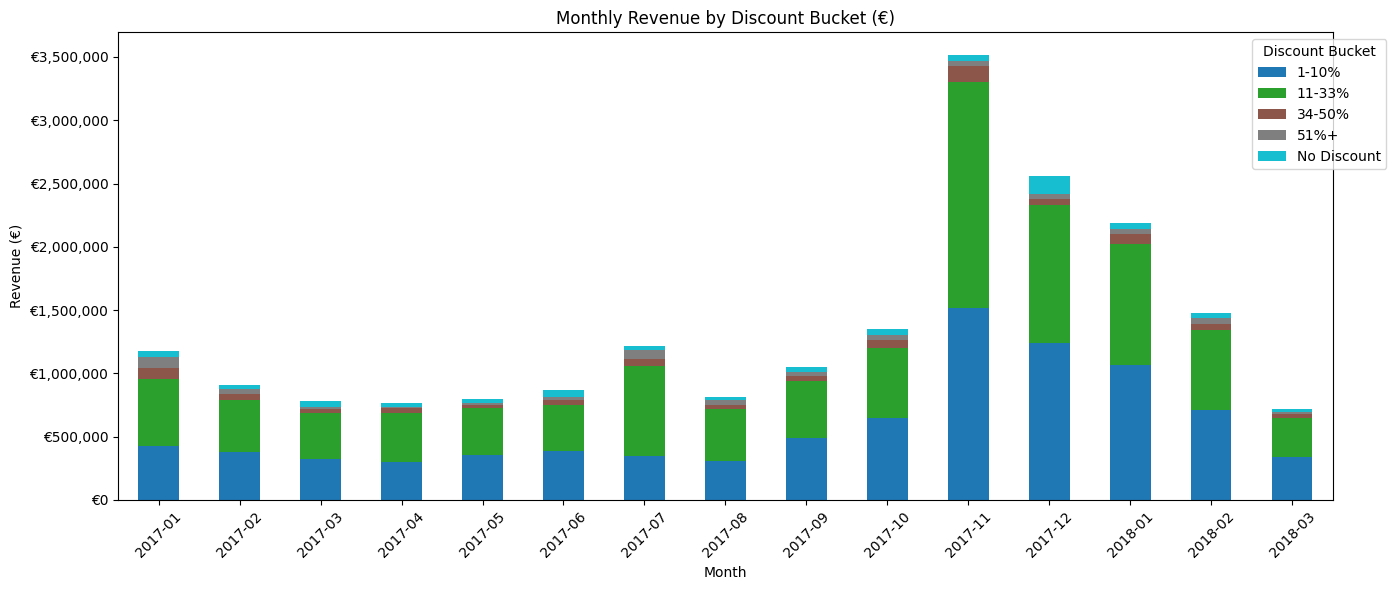

In [ ]:
# Pivot + plot revenue by bucket per month
pivot_revenue = monthly_buckets.pivot_table(
    index='month', columns='bucket_label', values='revenue', aggfunc='sum'
).fillna(0)

ax = pivot_revenue.plot(
    kind='bar', stacked=True, figsize=(14, 6),
    colormap='tab10', title='Monthly Revenue by Discount Bucket (€)'
)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(title='Discount Bucket', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Revenue Top Product

In [ ]:
# ── REVENUE + TOP PRODUCTS WITH DESCRIPTION ──────────────────────────────

total_revenue = mydata['t_price'].sum()
total_orders  = mydata['order_id'].nunique()

print(f'Total Revenue        : €{total_revenue:,.2f}')
print(f'Total Orders         : {total_orders:,}')
print(f'Avg Revenue per Order: €{total_revenue/total_orders:.2f}')

Total Revenue        : €20,195,276.30
Total Orders         : 78,729
Avg Revenue per Order: €256.52


In [ ]:
#generic top revenue, use head(n) to filter to top n
top_revenue = (
    mydata
    .groupby('sku')
    .agg(
        revenue       = ('t_price', 'sum'),
        units_sold    = ('product_quantity', 'sum'),
        avg_discount  = ('discount', 'mean'),
        avg_price_paid= ('unit_price', 'mean')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

top_revenue_15  = top_revenue.head(15).copy()
top_sku_list    = top_revenue_15['sku'].tolist()

print(top_revenue.head(15).to_string(index=False))


    sku   revenue  units_sold  avg_discount  avg_price_paid
APP2072 472086.93      427.00         10.61          988.33
APP2489 450851.00      389.00          3.48         1118.65
APP2485 376790.00      410.00          3.49          886.94
APP2477 272633.00      337.00          3.27          782.53
APP2483 270186.00      294.00          3.30          888.64
LGE0044 233610.00      390.00          5.35          566.95
APP2488 231957.00      213.00          2.80         1058.45
APP1970 183941.00      439.00         13.96          360.50
APP2484 174610.00      190.00          3.20          889.64
APP2479 173126.00      214.00          2.34          790.06
WDT0183 159705.00      945.00         18.11          138.40
APP2446 154569.52      344.00         13.81          387.27
APP1922 153224.00      856.00          9.92          161.25
APP1190 149800.00     2140.00         21.11           55.22
APP2478 135103.00      167.00          3.05          784.32


In [ ]:
# Merge top products with name + description
prod_info = prod[['sku', 'name', 'desc']].drop_duplicates(subset='sku')

top_revenue_15_full = top_revenue.head(15).merge(prod_info, on='sku', how='left')
top_revenue__15_full = top_revenue_15_full[[
    'sku', 'name', 'desc',
    'revenue', 'units_sold',
    'avg_price_paid', 'avg_discount'
]]
print(top_revenue_15_full.to_string(index=False))

    sku   revenue  units_sold  avg_discount  avg_price_paid                                                                 name                                                                                 desc
APP2072 472086.93      427.00         10.61          988.33            Apple MacBook Air 13 "Core i5 18GHz | 8GB RAM | 128GB SSD                            laptop MacBook Air 13 inch i5 18GHz 8GB RAM and 128GB SSD
APP2489 450851.00      389.00          3.48         1118.65                                       Apple iPhone 64GB Space Gray X                                                               New Free iPhone 64GB X
APP2485 376790.00      410.00          3.49          886.94                                        Apple iPhone 8 Plus 64GB Gold                                                  Apple iPhone 8 Plus 64GB Gold color
APP2477 272633.00      337.00          3.27          782.53                                       Apple iPhone 64GB Space Gray 8                

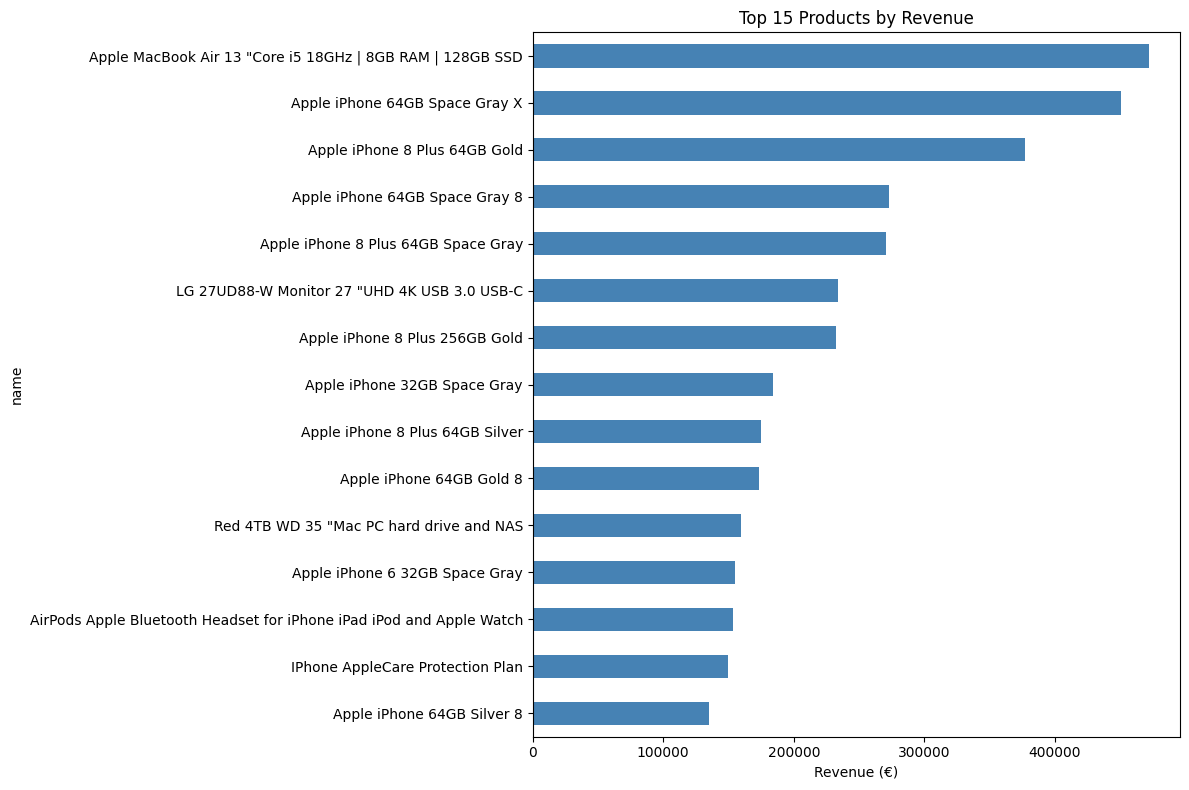

In [ ]:
# Plot top 15 by revenue
top_revenue_15_full.set_index('name')['revenue'].sort_values().plot(
    kind='barh', figsize=(12, 8), color='steelblue',
    title='Top 15 Products by Revenue'
)
plt.xlabel('Revenue (€)')
plt.tight_layout()
plt.show()

### Top SKU Analysis

In [ ]:
#there are a lot of orders of the top sku
top_sku_list = top_revenue["sku"].head(15).tolist() #this is probably not unique but i dont wanna figure out how to get top 15 unique sku now
mydata["sku"].isin(top_sku_list).sum()

np.int64(7041)

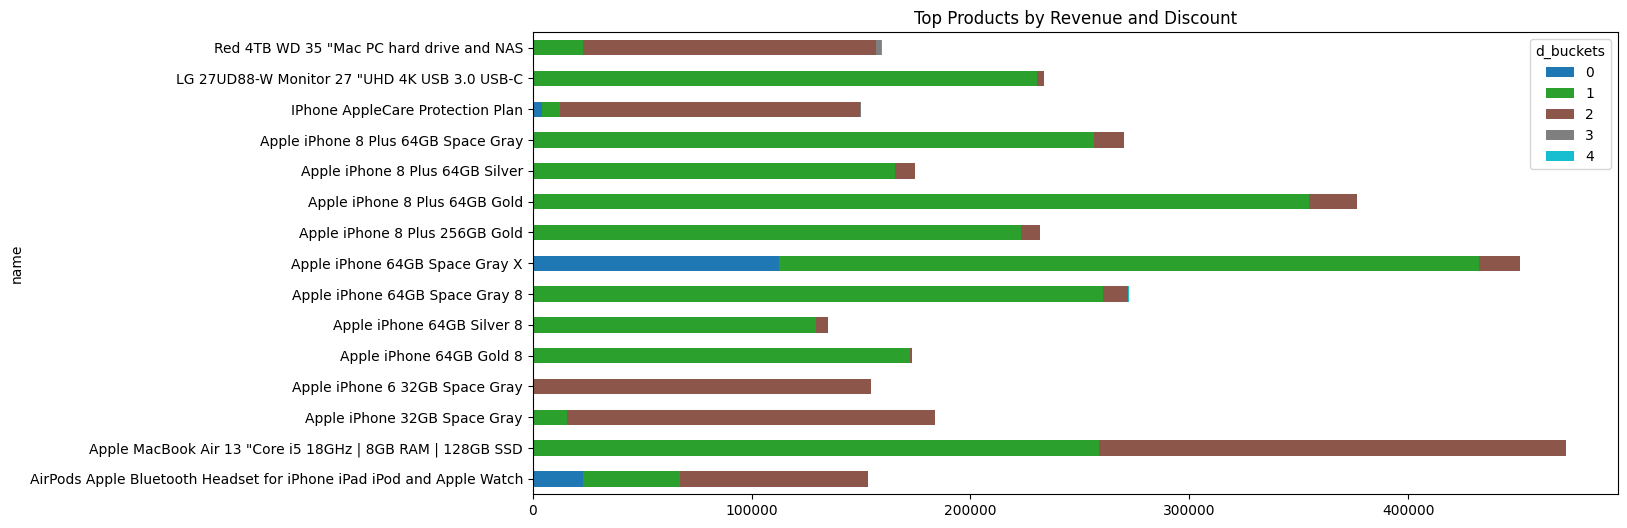

In [ ]:
top_15_sku = mydata[mydata["sku"].astype(str).isin(top_sku_list)]
top_15_sku_rev_grouped = top_15_sku.groupby(["sku", "d_buckets", "name"]).agg(revenue=("t_price", "sum"),)
pivot_top = top_15_sku_rev_grouped.pivot_table(
    index='name', columns='d_buckets', values='revenue'
)

ax = pivot_top.plot(
    kind='barh', stacked=True, figsize=(14, 6),
    colormap='tab10', title='Top Products by Revenue and Discount'
)


# Second Analysis (Product Category, Black Friday, some repeats)


### Generate Product Categories (Enayatul)

In [ ]:
# product categorization using regex on name_x
def categorize(name):
    name = str(name).lower()
    if re.search(r'iphone|samsung.*(s\d|a\d)|smartphone|huawei|móvil|movil', name): return 'Smartphones'
    elif re.search(r'macbook|laptop|notebook|portatil',                      name): return 'Laptops'
    elif re.search(r'ipad|tablet',                                            name): return 'Tablets'
    elif re.search(r'ssd|hard drive|hdd|storage|memory',                     name): return 'Storage'
    elif re.search(r'monitor|display|tv |television|screen',                  name): return 'Monitors & TVs'
    elif re.search(r'cable|charger|cargador|adapter|hub|usb|lightning|hdmi',  name): return 'Cables & Accessories'
    elif re.search(r'case|funda|cover|carcasa|protector',                     name): return 'Cases & Protection'
    elif re.search(r'airpod|headphone|auricular|speaker|altavoz|audio|earphone', name): return 'Audio'
    elif re.search(r'watch|smartwatch|reloj',                                 name): return 'Wearables'
    elif re.search(r'printer|impresora|ink|tinta|toner',                      name): return 'Printers & Ink'
    elif re.search(r'camera|cámara|camara|gopro|lens',                        name): return 'Cameras'
    else:                                                                            return 'Other'

mydata['category'] = mydata['name'].apply(categorize)
print('Category distribution:')
print(mydata['category'].value_counts())


Category distribution:
category
Smartphones             22485
Storage                 18131
Other                   17235
Cables & Accessories    15676
Laptops                  9156
Tablets                  6381
Monitors & TVs           4137
Audio                    3004
Cases & Protection       1974
Wearables                1003
Printers & Ink            771
Cameras                   197
Name: count, dtype: int64


### Revenue x Category

                      No Discount  Discounted
category                                     
Cameras                   5982.66    34213.58
Printers & Ink            6259.00    70698.25
Wearables                  809.83    92762.48
Audio                    18744.81   510840.82
Cases & Protection       77775.25   568094.33
Cables & Accessories     32252.51  1288225.84
Monitors & TVs           44881.40  1358722.62
Laptops                  21304.64  1790998.93
Tablets                 135255.17  1883807.69
Other                   123916.75  2745260.06
Storage                  36127.90  3863929.98
Smartphones             175383.24  5309028.56


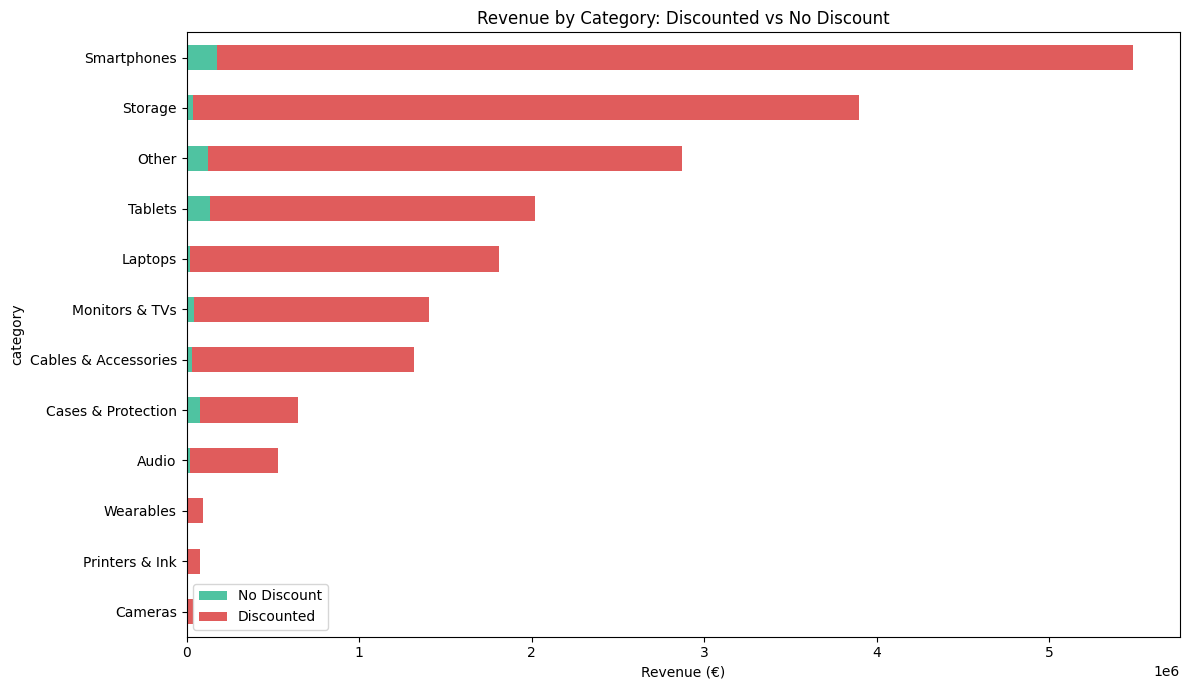

In [ ]:
# BY CATEGORY: revenue discounted vs not
pivot_cat = mydata.groupby(['category','is_discounted'])['t_price'].sum().unstack().fillna(0)
pivot_cat.columns = ['No Discount','Discounted']
pivot_cat = pivot_cat.sort_values('Discounted', ascending=True)
print(pivot_cat.to_string())

pivot_cat.plot(
    kind='barh', stacked=True, figsize=(12,7),
    color=['#4fc3a1','#e05c5c'],
    title='Revenue by Category: Discounted vs No Discount'
)
plt.xlabel('Revenue (€)')
plt.tight_layout()
plt.show()


### Smartphones: Revenue x Bucket x Month

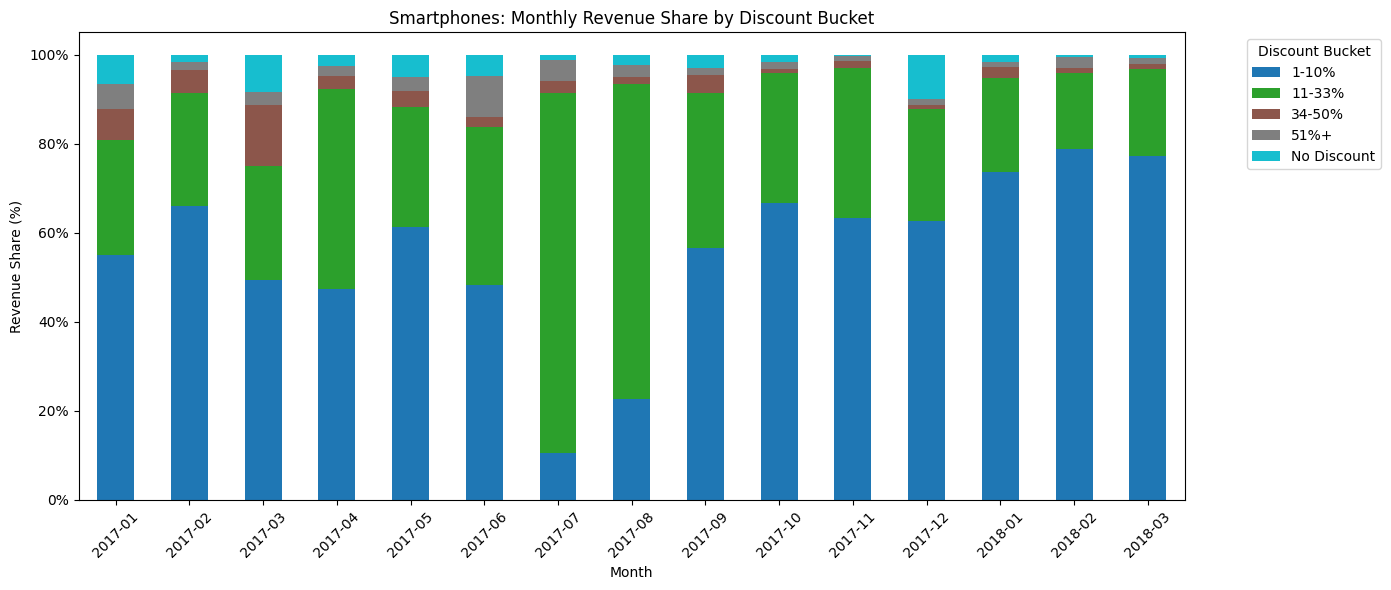

In [ ]:
smartphones = mydata[mydata["category"] == "Smartphones"].copy()

smartphones_monthly_buckets = (
    smartphones
    .groupby(["month", "d_buckets"])
    .agg(revenue=("t_price", "sum"))
    .reset_index()
)

smartphones_monthly_buckets["bucket_label"] = smartphones_monthly_buckets["d_buckets"].map(bucket_labels)

pivot_revenue = smartphones_monthly_buckets.pivot_table(
    index="month",
    columns="bucket_label",
    values="revenue",
    aggfunc="sum"
).fillna(0)


monthly_total = pivot_revenue.sum(axis=1)

# Percentages
pivot_share = pivot_revenue.divide(monthly_total, axis=0)  # each row sums to 1.0


ax = pivot_share.plot(
    kind="bar", stacked=True, figsize=(14, 6),
    colormap="tab10",
    title="Smartphones: Monthly Revenue Share by Discount Bucket"
)

ax.set_xlabel("Month")
ax.set_ylabel("Revenue Share (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))  # e.g., 60%
ax.legend(title="Discount Bucket", bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

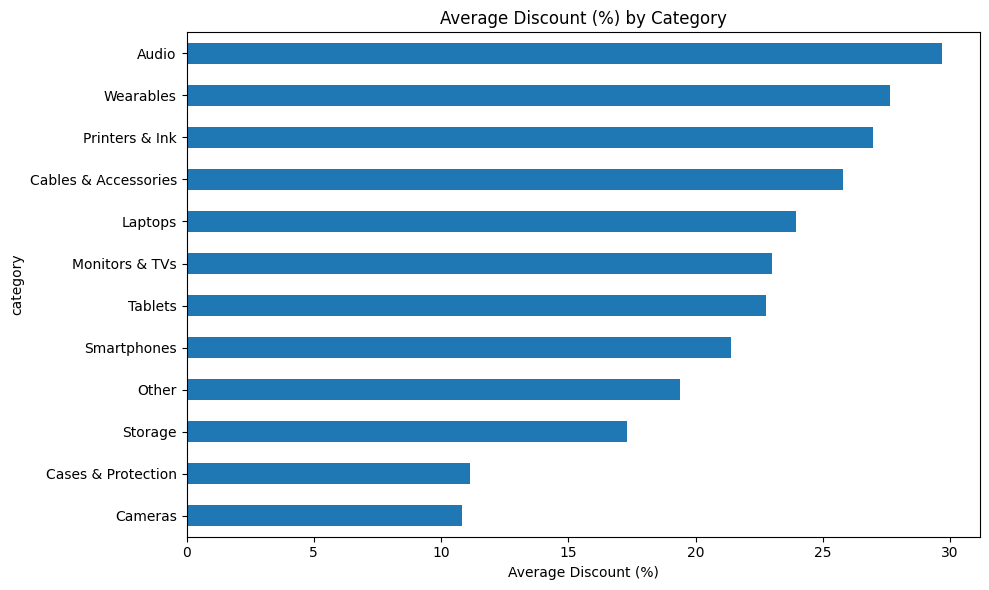

In [ ]:
# Average disount per category
avg_discount_cat = (
    mydata[mydata['discount'] > 0]
    .groupby('category')['discount']
    .mean()
    .sort_values(ascending=True)
)

avg_discount_cat.plot(
    kind='barh',
    figsize=(10,6),
    title='Average Discount (%) by Category'
)

plt.xlabel('Average Discount (%)')
plt.tight_layout()
plt.show()

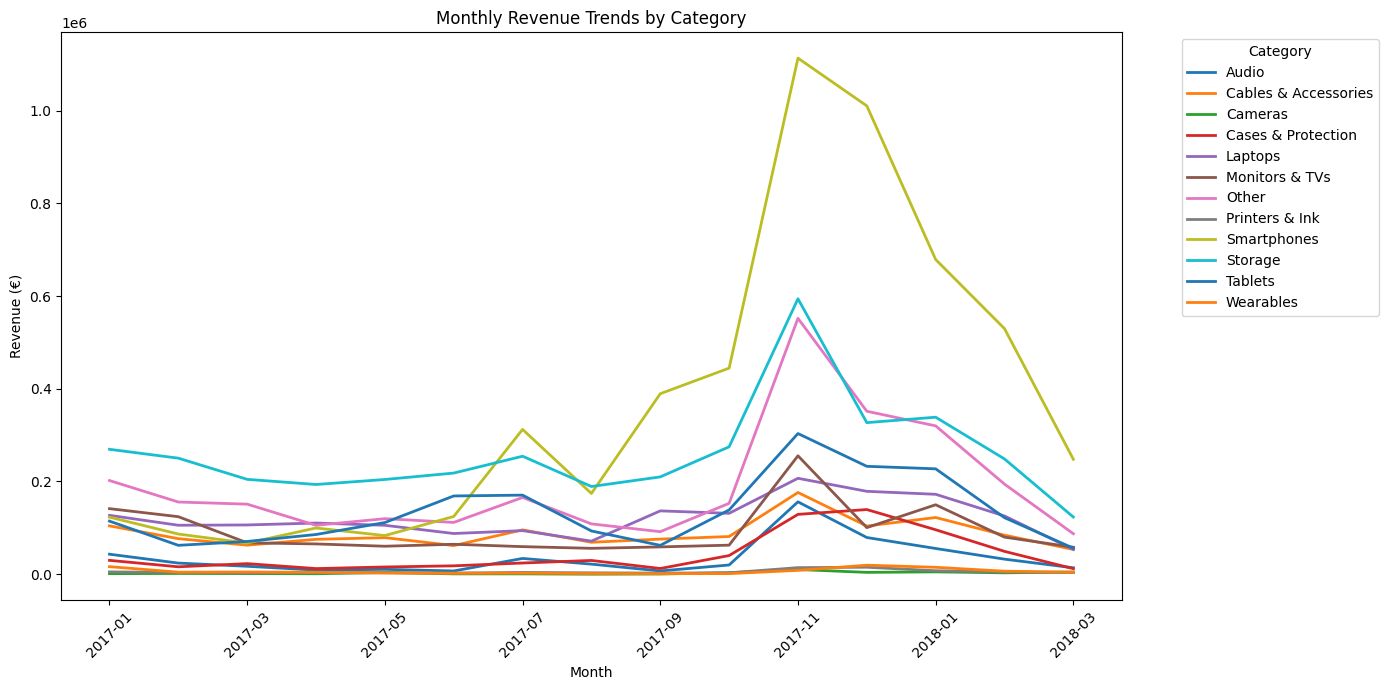

In [ ]:
# Do categories follow seasonal trend? - Yes, Black Friday and Christmas events
mydata['month'] = mydata['date'].dt.to_period('M').astype(str)

cat_month = (
    mydata
    .groupby(['month', 'category'])
    .agg(
        revenue=('t_price', 'sum'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

pivot_cat_month = cat_month.pivot(
    index='month',
    columns='category',
    values='revenue'
).fillna(0)

ax = pivot_cat_month.plot(
    figsize=(14, 7),
    linewidth=2,
    title='Monthly Revenue Trends by Category'
)

ax.set_xlabel('Month')
ax.set_ylabel('Revenue (€)')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

### Generate Price Based Categories; Plot Price Cat x Revenue

/tmp/ipykernel_795/4031817703.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_tier = mydata.groupby(['price_tier','is_discounted'])['t_price'].sum().unstack().fillna(0)


                    No Discount  Discounted
price_tier                                 
Budget (<€50)          59198.05  1074799.11
Mid (€50-200)         216795.55  4831315.48
Premium (€200-500)    156709.92  5452633.21
Luxury (€500+)        245989.64  8157835.34


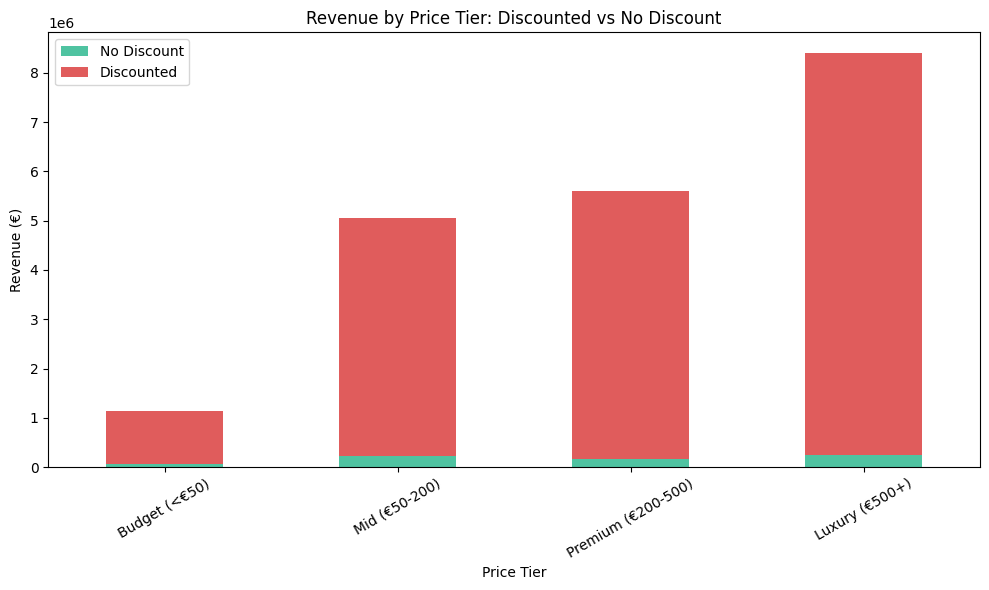

In [ ]:
# BY PRICE TIER: revenue discounted vs not
mydata['price_tier'] = pd.cut(
    mydata['price'],
    bins  =[0, 50, 200, 500, 99999],
    labels=['Budget (<€50)','Mid (€50-200)','Premium (€200-500)','Luxury (€500+)']
)

pivot_tier = mydata.groupby(['price_tier','is_discounted'])['t_price'].sum().unstack().fillna(0)
pivot_tier.columns = ['No Discount','Discounted']
print(pivot_tier.to_string())

pivot_tier.plot(
    kind='bar', stacked=True, figsize=(10,6),
    color=['#4fc3a1','#e05c5c'],
    title='Revenue by Price Tier: Discounted vs No Discount'
)
plt.xlabel('Price Tier')
plt.ylabel('Revenue (€)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Revenue x Discount x Month

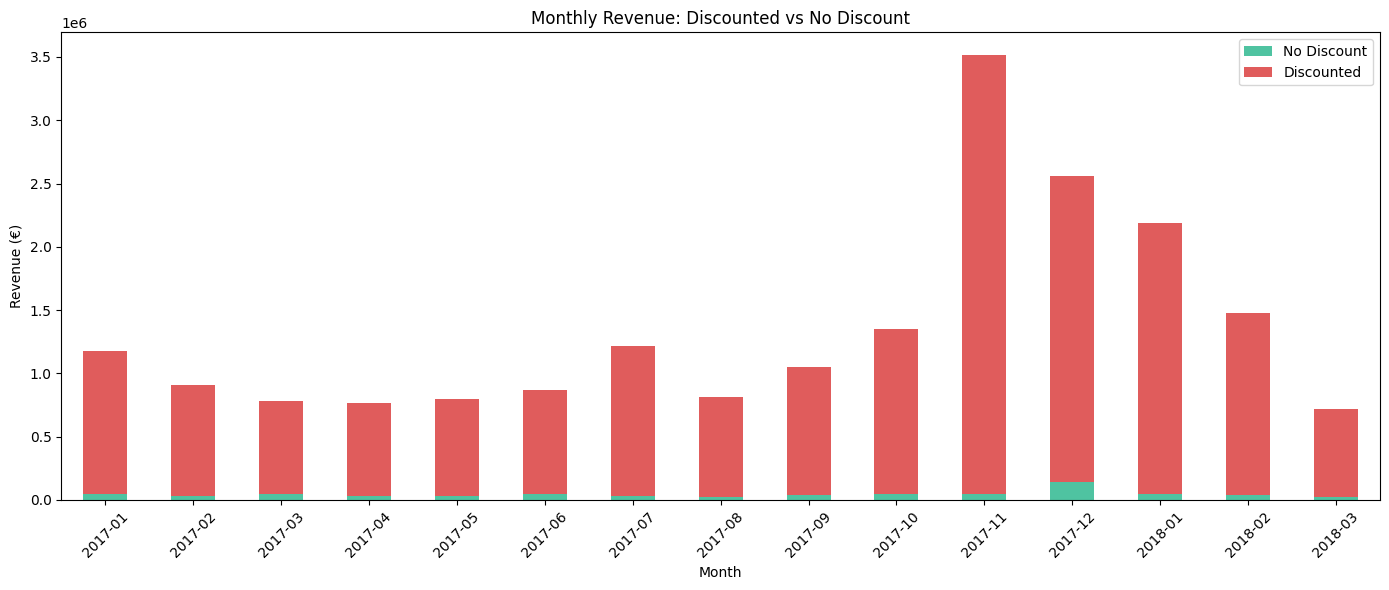

In [ ]:
# BY SEASONALITY: revenue discounted vs not
pivot_month = mydata.groupby(['month','is_discounted'])['t_price'].sum().unstack().fillna(0)
pivot_month.columns = ['No Discount','Discounted']

pivot_month.plot(
    kind='bar', stacked=True, figsize=(14,6),
    color=['#4fc3a1','#e05c5c'],
    title='Monthly Revenue: Discounted vs No Discount'
)
plt.xlabel('Month')
plt.ylabel('Revenue (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


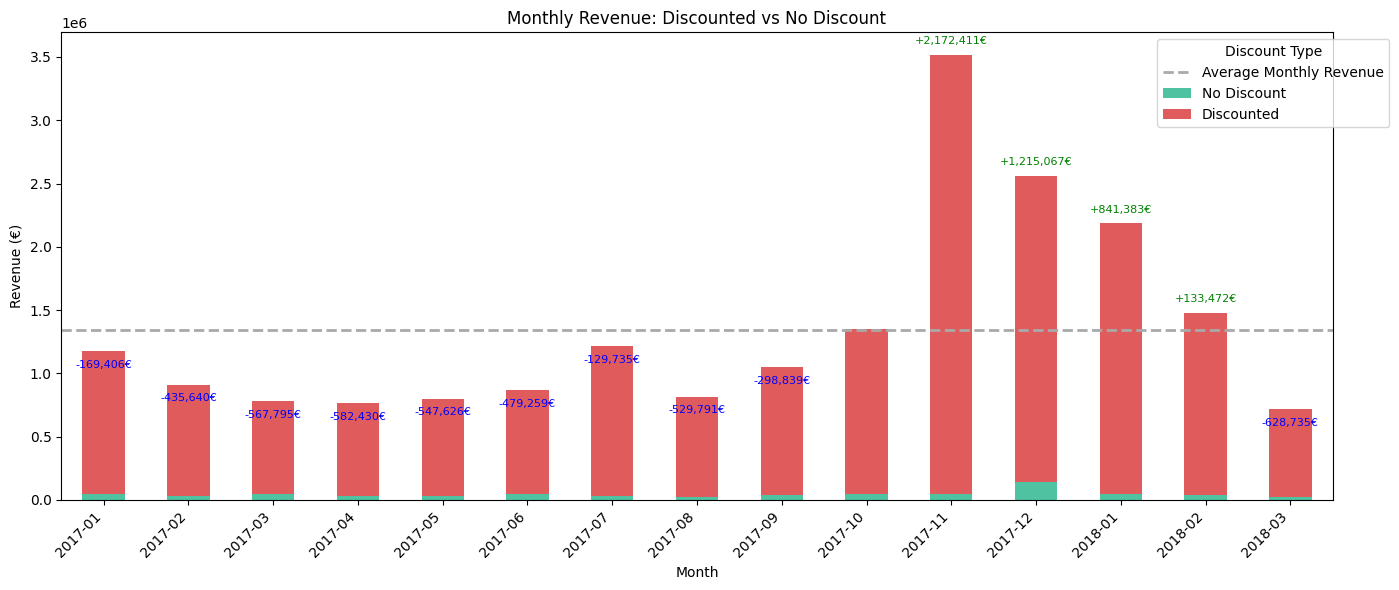

In [ ]:
# 1) Compute total monthly revenue and average
pivot_month["total"] = pivot_month["No Discount"] + pivot_month["Discounted"]
avg_revenue = pivot_month["total"].mean()

# 2) Plot stacked bar chart
ax = pivot_month[["No Discount", "Discounted"]].plot(
    kind="bar", stacked=True, figsize=(14, 6),
    color=["#4fc3a1", "#e05c5c"],
    title="Monthly Revenue: Discounted vs No Discount"
)

# 3) Add horizontal line at average monthly revenue
ax.axhline(
    y=avg_revenue,
    color="darkgray",
    linestyle="--",
    linewidth=2,
    label="Average Monthly Revenue"
)

# 4) Optional: annotate how far each month is above/below average
for idx, (month, row) in enumerate(pivot_month.iterrows()):
    total = row["total"]
    diff = total - avg_revenue
    if abs(diff) > 0.05 * avg_revenue:  # only annotate clearly above/below
        va = "bottom" if diff > 0 else "top"
        ytext = total + (0.05 * avg_revenue) if diff > 0 else total - (0.05 * avg_revenue)
        ax.annotate(
            f"{diff:+,.0f}€",
            xy=(idx, total),
            xytext=(idx, ytext),
            fontsize=8,
            color="green" if diff > 0 else "blue",
            ha="center",
            va=va,
        )

ax.set_xlabel("Month")
ax.set_ylabel("Revenue (€)")
ax.legend(title="Discount Type", bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

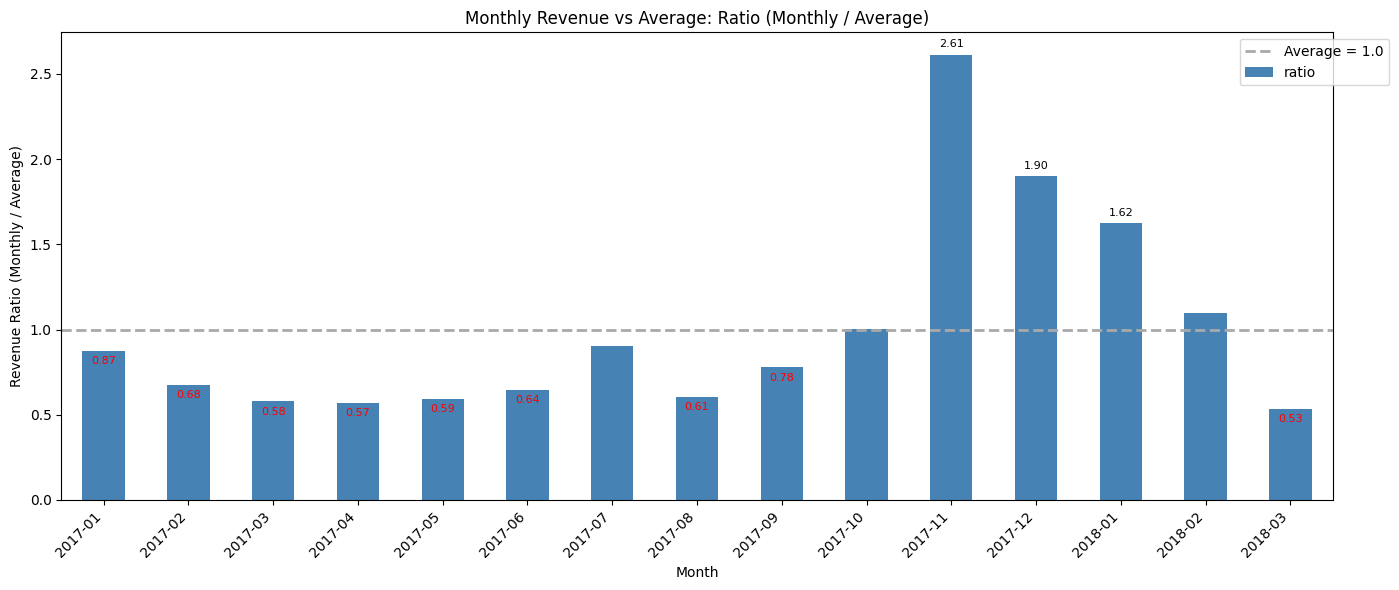

In [ ]:
pivot_month = (
    mydata
    .groupby(["month", "is_discounted"])["t_price"]
    .sum()
    .unstack()
    .fillna(0)
)
pivot_month.columns = ["No Discount", "Discounted"]

# 1) Compute total monthly revenue (from t_price) and average
pivot_month["total"] = pivot_month["No Discount"] + pivot_month["Discounted"]
avg_revenue = pivot_month["total"].mean()

# 2) Compute ratio: monthly revenue / average monthly revenue
pivot_month["ratio"] = pivot_month["total"] / avg_revenue

# 3) Plot the ratio graph
ax = pivot_month["ratio"].plot(
    kind="bar",
    figsize=(14, 6),
    color="steelblue",
    title="Monthly Revenue vs Average: Ratio (Monthly / Average)"
)

# 4) Add horizontal line at 1.0 (average = 1.0)
ax.axhline(
    y=1.0,
    color="darkgray",
    linestyle="--",
    linewidth=2,
    label="Average = 1.0"
)

# 5) Optional: annotate months that are clearly above/below average
for idx, (month, row) in enumerate(pivot_month.iterrows()):
    ratio = row["ratio"]
    if ratio > 1.1 or ratio < 0.9:  # only annotate clearly above or below
        va = "bottom" if ratio > 1.0 else "top"
        ytext = ratio + 0.03 if ratio > 1.0 else ratio - 0.03
        ax.annotate(
            f"{ratio:.2f}",
            xy=(idx, ratio),
            xytext=(idx, ytext),
            fontsize=8,
            color="black" if ratio > 1.0 else "red",
            ha="center",
            va=va,
        )

ax.set_xlabel("Month")
ax.set_ylabel("Revenue Ratio (Monthly / Average)")
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Quantity Sold x SKU

    sku                                                                 name  units_sold  orders   revenue
APP1190                                     IPhone AppleCare Protection Plan     2140.00    1979 149800.00
APP0698                Apple Lightning Cable Connector to USB 1m White (OEM)     1390.00     885  34750.00
WDT0183                             Red 4TB WD 35 "Mac PC hard drive and NAS      945.00     587 159705.00
APP0927                   EarPods Apple Headphones with Remote and Mic (OEM)      927.00     739  32445.00
APP1922 AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch      856.00     819 153224.00
KIN0137                   Kingston Memory Card microSDHC UHS Class 1 | 16 GB      813.00      10   7308.87
SAM0074                                       Samsung 850 EVO SSD Disk 500GB      650.00     596 116993.50
APP1214                                                  Apple Magic Mouse 2      615.00     581  54735.00
CRU0051                              

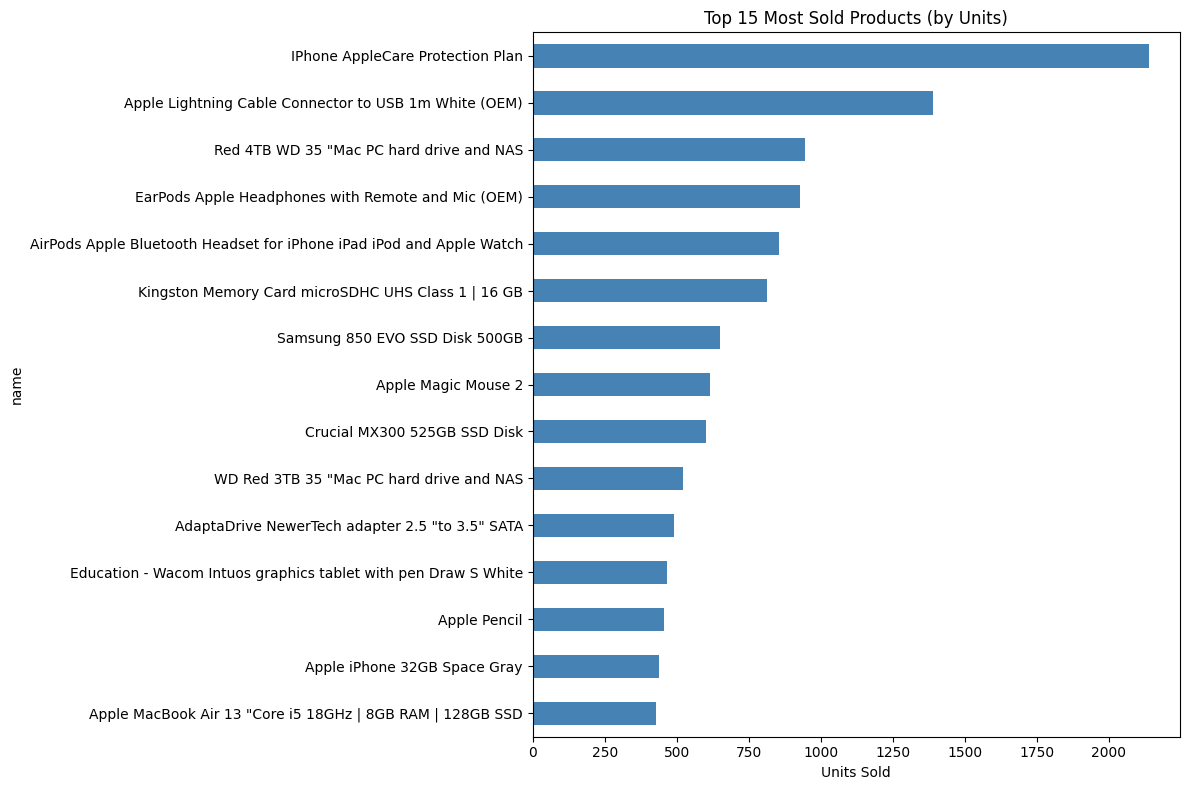

In [ ]:
# ── 1. MOST SOLD PRODUCTS (by units) ─────────────────────────────────────
top_sold = (
    mydata
    .groupby(['sku', 'name'])
    .agg(
        units_sold = ('product_quantity', 'sum'),
        orders     = ('order_id', 'nunique'),
        revenue    = ('t_price', 'sum')
    )
    .reset_index()
    .sort_values('units_sold', ascending=False)
    .head(15)
)
print(top_sold.to_string(index=False))

# Plot
top_sold.set_index('name')['units_sold'].sort_values().plot(
    kind='barh', figsize=(12, 8), color='steelblue',
    title='Top 15 Most Sold Products (by Units)'
)
plt.xlabel('Units Sold')
plt.tight_layout()
plt.show()

### Month x Revenue (reprise)

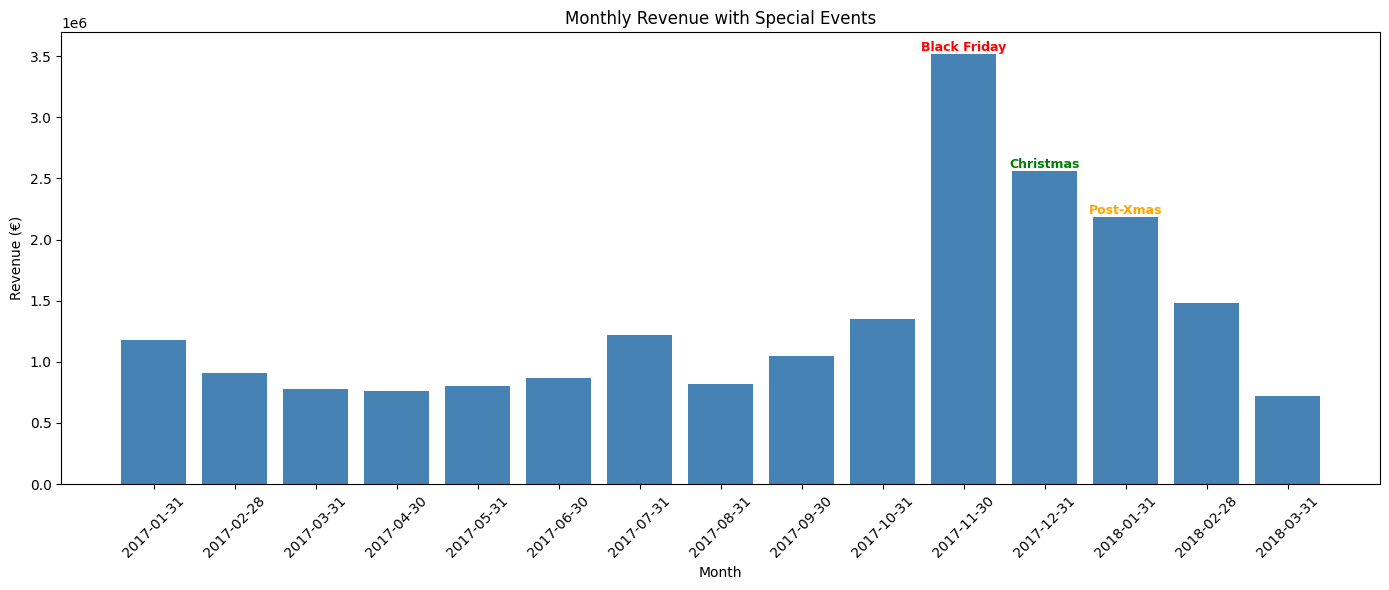

In [ ]:
# ── 2. SEASONALITY & SPECIAL DATES ───────────────────────────────────────

# Monthly revenue with special event labels
monthly_rev = (
    mydata
    .resample('ME', on='date')
    .agg(
        orders  = ('order_id', 'nunique'),
        revenue = ('t_price', 'sum')
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(monthly_rev['date'].astype(str), monthly_rev['revenue'], color='steelblue', label='Revenue')
ax.set_title('Monthly Revenue with Special Events')
ax.set_ylabel('Revenue (€)')
ax.set_xlabel('Month')
plt.xticks(rotation=45)

# Add event labels
for idx, row in monthly_rev.iterrows():
    date_str = str(row['date'])
    if '2017-11' in date_str:
        ax.annotate('Black Friday', xy=(idx, row['revenue']),
                    xytext=(idx, row['revenue'] + 20000),
                    fontsize=9, color='red', ha='center', fontweight='bold')
    if '2017-12' in date_str:
        ax.annotate('Christmas', xy=(idx, row['revenue']),
                    xytext=(idx, row['revenue'] + 20000),
                    fontsize=9, color='green', ha='center', fontweight='bold')
    if '2018-01' in date_str:
        ax.annotate('Post-Xmas', xy=(idx, row['revenue']),
                    xytext=(idx, row['revenue'] + 20000),
                    fontsize=9, color='orange', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Black Friday -> Christmas, weeklies (Generation and Plotting)

=== Black Friday 2017 ===
Week before BF : orders=809  revenue=€250,861
BF week        : orders=5,444  revenue=€1,775,453
Week after BF  : orders=2,454  revenue=€690,711

=== Christmas 2017 ===
Dec 1-17 (pre) : orders=3,217  revenue=€1,013,354
Dec 18-31 (Xmas): orders=5,037  revenue=€1,431,025


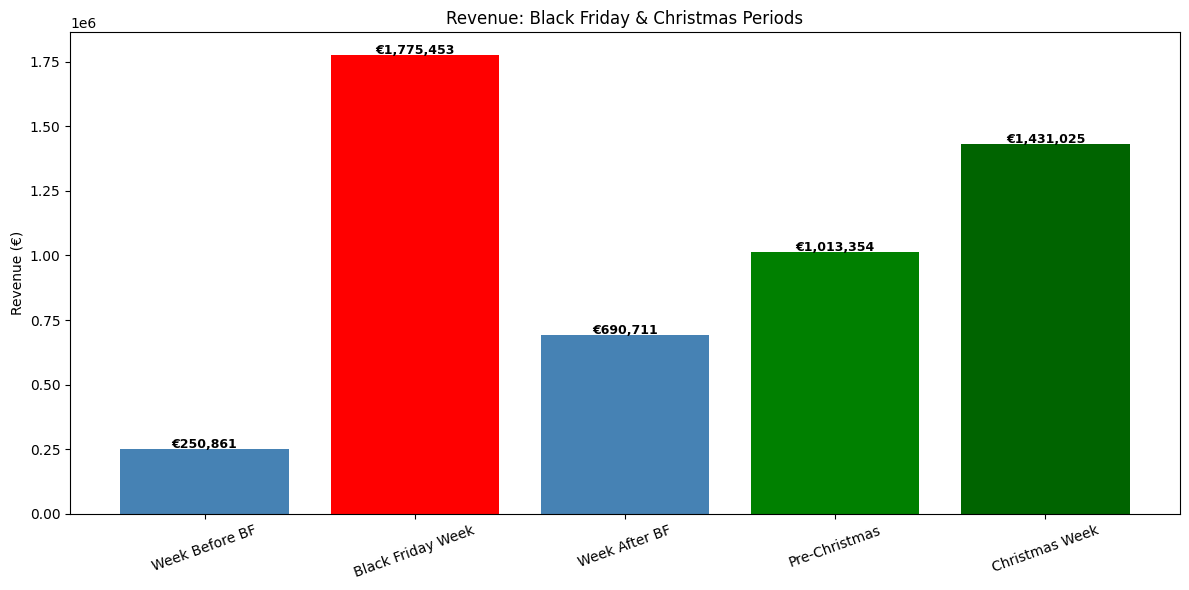

In [ ]:
# Black Friday week vs normal week comparison
mydata['date_only'] = mydata['date'].dt.date

bf_week    = mydata[(mydata['date'] >= '2017-11-20') & (mydata['date'] <= '2017-11-26')]
week_before = mydata[(mydata['date'] >= '2017-11-13') & (mydata['date'] <= '2017-11-19')]
week_after  = mydata[(mydata['date'] >= '2017-11-27') & (mydata['date'] <= '2017-12-03')]

xmas_week   = mydata[(mydata['date'] >= '2017-12-18') & (mydata['date'] <= '2017-12-31')]
pre_xmas    = mydata[(mydata['date'] >= '2017-12-01') & (mydata['date'] <= '2017-12-17')]

print('=== Black Friday 2017 ===')
print(f'Week before BF : orders={week_before["order_id"].nunique():,}  revenue=€{week_before["t_price"].sum():,.0f}')
print(f'BF week        : orders={bf_week["order_id"].nunique():,}  revenue=€{bf_week["t_price"].sum():,.0f}')
print(f'Week after BF  : orders={week_after["order_id"].nunique():,}  revenue=€{week_after["t_price"].sum():,.0f}')

print('\n=== Christmas 2017 ===')
print(f'Dec 1-17 (pre) : orders={pre_xmas["order_id"].nunique():,}  revenue=€{pre_xmas["t_price"].sum():,.0f}')
print(f'Dec 18-31 (Xmas): orders={xmas_week["order_id"].nunique():,}  revenue=€{xmas_week["t_price"].sum():,.0f}')

# Bar comparison chart
events = ['Week Before BF', 'Black Friday Week', 'Week After BF', 'Pre-Christmas', 'Christmas Week']
revenues = [
    week_before['t_price'].sum(),
    bf_week['t_price'].sum(),
    week_after['t_price'].sum(),
    pre_xmas['t_price'].sum(),
    xmas_week['t_price'].sum()
]
colors = ['steelblue', 'red', 'steelblue', 'green', 'darkgreen']

plt.figure(figsize=(12, 6))
bars = plt.bar(events, revenues, color=colors)
plt.title('Revenue: Black Friday & Christmas Periods')
plt.ylabel('Revenue (€)')
plt.xticks(rotation=20)
for bar, val in zip(bars, revenues):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'€{val:,.0f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

#### Black Friday Descriptives

In [ ]:
#black friday + xmas week orders and revenue
print(bf_week['order_id'].nunique())
print(bf_week['t_price'].sum())
print(xmas_week['order_id'].nunique())
print(xmas_week['t_price'].sum())

# Black Friday uplift
bf_week     = mydata[(mydata['date'] >= '2017-11-20') & (mydata['date'] <= '2017-11-26')]
week_before = mydata[(mydata['date'] >= '2017-11-13') & (mydata['date'] <= '2017-11-19')]
print(f"BF uplift: {bf_week['order_id'].nunique() / week_before['order_id'].nunique():.2f}x")
# → 6.73x

# Christmas uplift
xmas_week = mydata[(mydata['date'] >= '2017-12-18') & (mydata['date'] <= '2017-12-31')]
pre_xmas  = mydata[(mydata['date'] >= '2017-12-01') & (mydata['date'] <= '2017-12-17')]
print(f"Xmas uplift: {xmas_week['order_id'].nunique() / pre_xmas['order_id'].nunique():.2f}x")
# → 1.57x

5444
1775453.3199999998
5037
1431024.8199999998
BF uplift: 6.73x
Xmas uplift: 1.57x


### Price x Category (Descriptives & Plotting)

In [ ]:
# ── 3. PRICE DISTRIBUTION BY CATEGORY ────────────────────────────────────

# Summary stats per category
price_by_cat = (
    mydata
    .groupby('category')['price']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .reset_index()
    .rename(columns={'mean':'avg_price', 'median':'median_price',
                     'min':'min_price', 'max':'max_price', 'count':'products'})
    .sort_values('avg_price', ascending=False)
)
print(price_by_cat.to_string(index=False))

            category  avg_price  median_price  min_price  max_price  products
  Cases & Protection     324.42        399.00       3.49     869.00      1974
             Tablets     303.63        119.00       6.99    1229.00      6381
      Monitors & TVs     301.23        227.00       9.99    1191.99      4137
         Smartphones     236.21         60.99       2.99    1159.00     22485
             Laptops     193.16         89.00       3.99    1219.00      9156
             Storage     181.63        134.99       4.99    1209.99     18131
             Cameras     178.75        181.99      22.99     429.99       197
               Audio     165.34        129.99      14.99     799.00      3004
               Other     157.47         87.00       2.99    1241.31     17235
           Wearables      92.06         49.99       4.99     419.00      1003
      Printers & Ink      91.46         79.99       8.99     337.59       771
Cables & Accessories      76.62         39.99       3.99    1047

/tmp/ipykernel_795/1576578751.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=categories, vert=True)


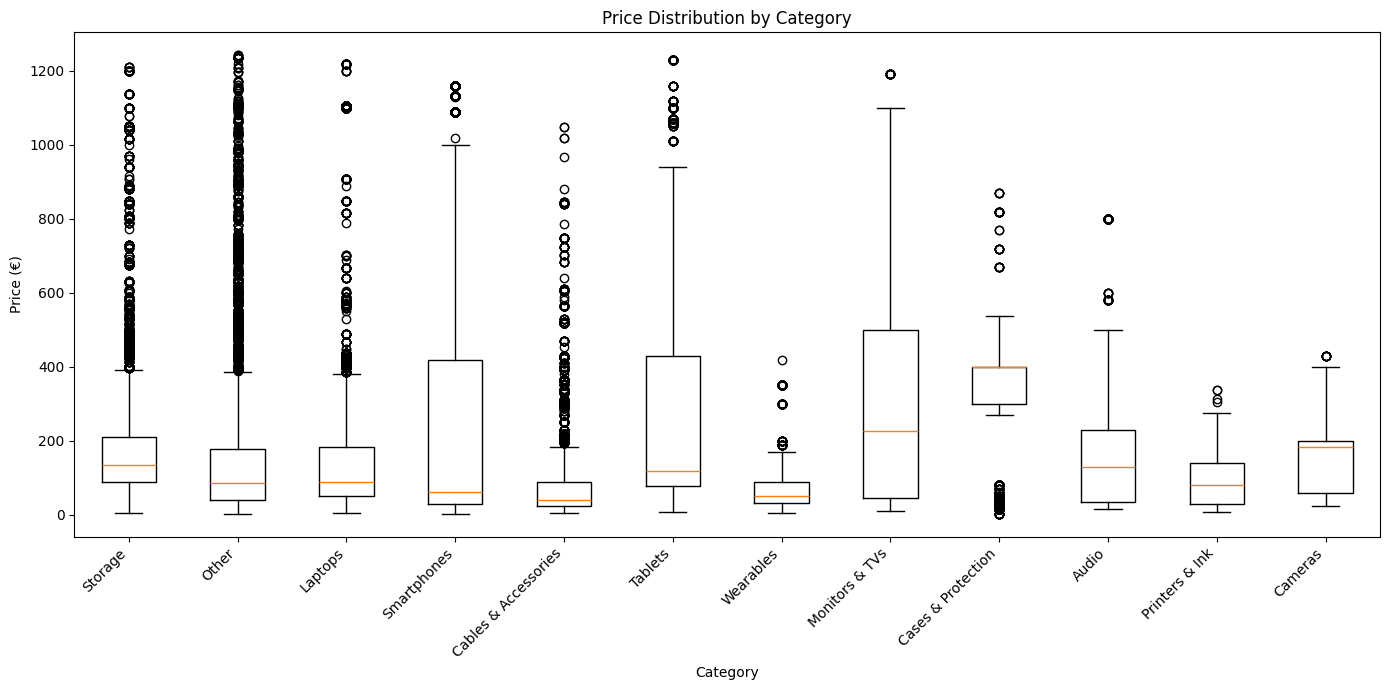

In [ ]:
# Boxplot: price distribution per category
fig, ax = plt.subplots(figsize=(14, 7))

categories = mydata['category'].unique()
data_to_plot = [mydata[mydata['category'] == cat]['price'].dropna().values
                for cat in categories]

ax.boxplot(data_to_plot, labels=categories, vert=True)
ax.set_title('Price Distribution by Category')
ax.set_ylabel('Price (€)')
ax.set_xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

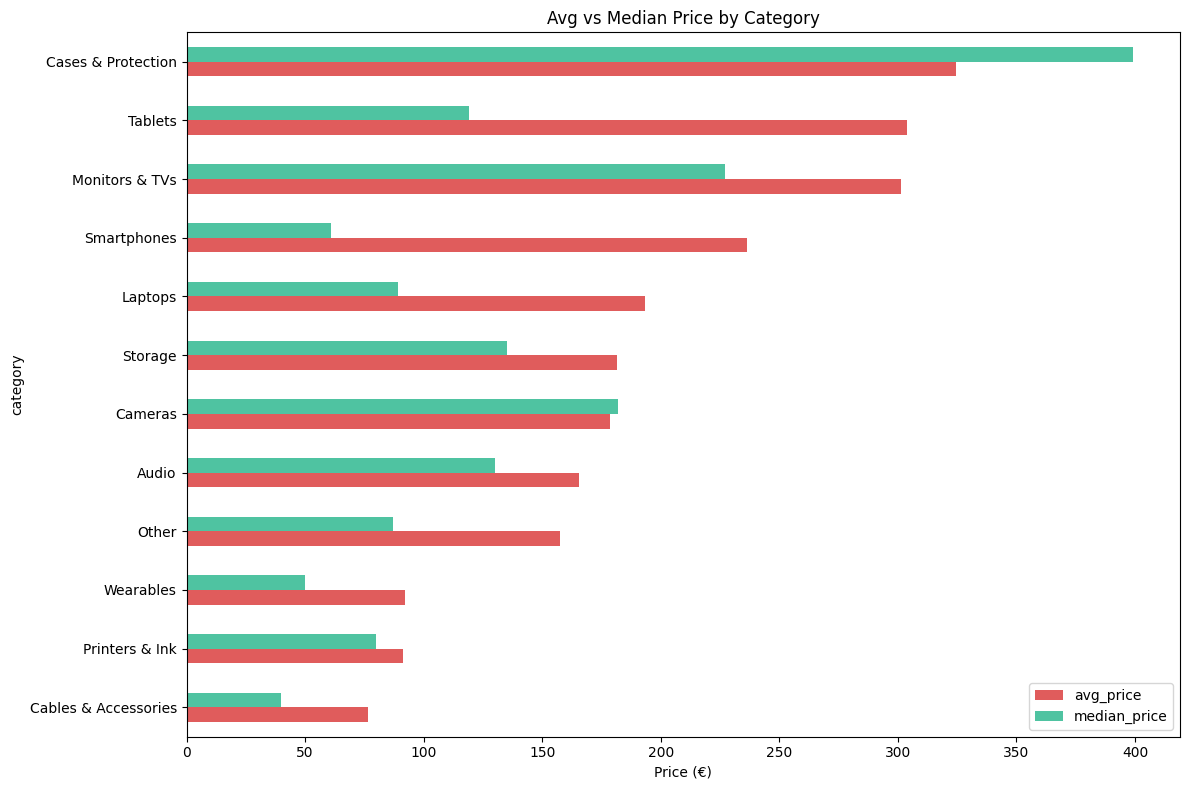

In [ ]:
# Bar chart: avg vs median price per category
price_by_cat.set_index('category')[['avg_price','median_price']].sort_values('avg_price').plot(
    kind='barh', figsize=(12, 8),
    color=['#e05c5c','#4fc3a1'],
    title='Avg vs Median Price by Category'
)
plt.xlabel('Price (€)')
plt.tight_layout()
plt.show()

### More general Descriptives

In [ ]:
#unique products
print(mydata["sku"].nunique())
print(mydata["discount"].mean())

5836
20.55123221909692


In [ ]:
#discount range
disc_only = mydata[mydata['is_discounted']]
total_disc = len(disc_only)
for b, lbl in {1:'1-10%', 2:'11-33%', 3:'34-50%', 4:'51%+'}.items():
    cnt = (disc_only['d_buckets'] == b).sum()
    print(f"{lbl}: {cnt/total_disc*100:.2f}%")

1-10%: 28.80%
11-33%: 53.89%
34-50%: 9.73%
51%+: 7.58%


In [ ]:
# avg discounted
print(mydata[mydata['discount']>0]['discount'].mean().round(2))  # discounted only → 21.55%

21.55


In [ ]:
# Using resample
mydata.resample('ME', on='date')['t_price'].sum()['2018-01']

,t_price
date,
2018-01-31,2187735.14
